---
#<font color="#CA3532">Neurocomputing Practice 3 – Academic Year 2025–2026</font>
### School of Engineering – Autonomous University of Madrid

---
- Start date: Thursday, 08-04-2026
- Submission deadline: Thursday, 05-05-2023

---

Last updated: 01-04-2026

In [1]:
# Incluid vuestros nombres, pareja y grupo aquí: grupo 2461, pareja XX
estudiantes = [
    {'Marco Gómez Hernández': 'Marco Gómez Hernández, grupo 2461, pareja XX'},
    {'Ignacio García Hernanz': 'Ignacio García Hernanz, grupo 2461, pareja XX'},
    {'Eduard Andrei Moga': 'Eduard Andrei Moga, grupo 2461, pareja XX'}
]

Many binary classification problems do not have the same number of examples for each class. In these cases, the class distribution is said to be biased or unbalanced.

An example of this problem is found in speech recognizers that classify vowel sounds in European languages as either nasal or oral. Accuracy in classification is important for both classes, but it cannot be used in problems with unbalanced classes.

# <font color="#CA3532">Phoneme Dataset</font>


To characterize each vowel, five different attributes have been selected: the amplitudes of the first five harmonics (AHi), normalized by the total energy (Ene): AHi/Ene. Each harmonic can be positive if it corresponds to a local maximum in the spectrum, or negative otherwise.

In the *Phoneme Dataset*, there are two classes for the two types of sounds:
*	Class 0: nasal vowels (the majority class).
*	Class 1: oral vowels (the minority class).


In [2]:
# Details https://raw.githubusercontent.com/jbrownlee/Datasets/master/phoneme.names
dataset_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/phoneme.csv'

# <font color="#CA3532">Exploración de los datos</font>

In [3]:
from pandas import read_csv
from pandas import DataFrame
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
from collections import Counter

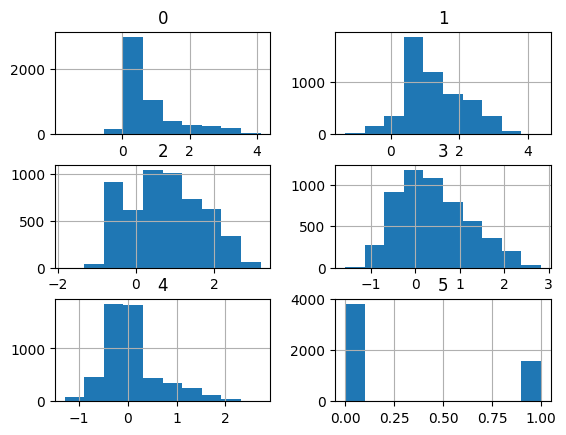

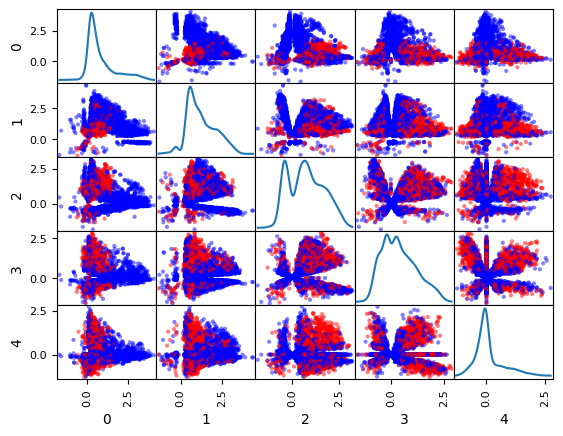

In [4]:
# define the dataset location
filename = dataset_url
# load the csv file as a data frame
df = read_csv(filename, header=None)
# histograms of all variables
df.hist()
pyplot.show()
# define a mapping of class values to colors
color_dict = {0: 'blue', 1: 'red'}
# map each row to a color based on the class value
colors = [color_dict[x] for x in df.values[:, -1]]
# drop the target variable
inputs = DataFrame(df.values[:, :-1])
# pairwise scatter plots of all numerical variables scatter_matrix(inputs, diagonal='kde', color=colors)
scatter_matrix(inputs, diagonal='kde', color=colors)
pyplot.show()

### Question 1: What is the class distribution of examples?  
Explain here what the previous plots represent and what you observe in them.

**Respuesta:**

**1. Histogramas univariantes (Primera figura):** 
Representan la distribución de frecuencias de cada una de las 6 variables del conjunto de datos. Las gráficas del 0 al 4 corresponden a las características de entrada (amplitudes de los armónicos), y la última a la clase objetivo.
*   **Variables 0, 1 y 4:** Presentan distribuciones numéricas continuas con sesgo positivo (asimetría hacia la derecha). La mayor concentración de datos se encuentra en torno a 0.
*   **Variable 2:** Muestra una distribución continua con una fuerte dispersión y ligera tendencia bimodal. Su rango aproximado es de $[-2, 3]$.
*   **Variable 3:** Tiene una distribución continua con forma pseudo-normal (acampanada), centrada en 0.
*   **Variable 5 (Clase objetivo):** El histograma de frecuencias discretas en 0 y 1 muestra explícitamente un **desbalanceo de clases severo**. La clase 0 (vocales nasales, la clase mayoritaria) agrupa aproximadamente 3800 muestras, frente a unas 1500 muestras de la clase 1 (vocales orales, minoritaria).

**2. Matriz de dispersión o Scatter Matrix (Segunda figura):** 
Muestra todas las combinaciones de pares posibles entre las 5 características de entrada.
*   **Diagonal principal:** Muestra la estimación de densidad de kernel (KDE) univariante para las 5 características de entrada, coincidiendo y suavizando las formas de los histogramas de la primera figura.
*   **Gráficos fuera de la diagonal (Dispersión bidimensional):** Reflejan cruces de variables por pares, con los puntos coloreados según su clase (Azul = Clase 0, Rojo = Clase 1).
*   **Separabilidad:** Se observa una superposición espacial masiva entre las clases en todas las proyecciones 2D. No existe una separabilidad lineal evidente en ninguno de los pares, lo que indica que es un problema de clasificación complejo no resoluble mediante fronteras de decisión simples.
*   **Varianza:** La clase 0 (azul) exhibe sistemáticamente una mayor varianza y amplitud en el espacio de características, mientras que la clase 1 (roja) tiende a concentrarse en densidades más cerradas.
*   **Estructuras de correlación:** Se aprecian distribuciones conjuntas con topologías no lineales fuertemente estructuradas (agrupaciones en forma de "V" o "X"), que son particularmente notorias en las intersecciones de las variables 2, 3 y 4.

# <font color="#CA3532">Modelling</font>

- In this practice, we will use [Keras](https://keras.io/)

- Keras is an open-source neural network library designed for experimenting with deep neural networks. Keras is modular, extensible, and easy to use.

- Keras can run on different backends. Here, it will be used with TensorFlow.

In [5]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

import keras as k
from keras.models import Sequential
from keras.layers import Dense

from sklearn.preprocessing import StandardScaler

I0000 00:00:1777501168.328532  260212 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777501168.458522  260212 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777501171.081997  260212 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [6]:
import random

# Fijamos la semilla para reproducibilidad
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
k.utils.set_random_seed(seed_value)
tf.config.experimental.enable_op_determinism()

In [7]:
dataset = np.loadtxt(dataset_url, delimiter=',')

print(dataset)

# -------------------------------------------------------------------------------
# Split the examples into features and classes. Store the number of features.
# -------------------------------------------------------------------------------

x = dataset[:, :-1]
x_size = x.shape[1]
y = dataset[:, -1]

[[ 1.24   0.875 -0.205 -0.078  0.067  0.   ]
 [ 0.268  1.352  1.035 -0.332  0.217  0.   ]
 [ 1.567  0.867  1.3    1.041  0.559  0.   ]
 ...
 [ 1.031  0.584  1.866  1.532 -0.671  1.   ]
 [ 0.15   0.933  2.363 -0.742 -0.617  0.   ]
 [ 0.137  0.714  1.35   0.972 -0.63   1.   ]]


In [8]:
# Results of the split and the number of features
print(x)
print(y)
print(x_size)

[[ 1.24   0.875 -0.205 -0.078  0.067]
 [ 0.268  1.352  1.035 -0.332  0.217]
 [ 1.567  0.867  1.3    1.041  0.559]
 ...
 [ 1.031  0.584  1.866  1.532 -0.671]
 [ 0.15   0.933  2.363 -0.742 -0.617]
 [ 0.137  0.714  1.35   0.972 -0.63 ]]
[0. 0. 0. ... 1. 0. 1.]
5


In [9]:
# Normalize the data (if necessary)
scaler = StandardScaler()
scaler.fit(x)
x = scaler.transform(x)

## <font color="#CA3532">Neural Network Definition</font>

- Each layer of the model has a set of defined properties (size, activation function, connectivity, etc.) which you can find at https://keras.io/api/layers/core_layers/dense/.

- We will use Keras' Sequential model to create a multi-layer feedforward neural network.


In [10]:
# Define the model with Keras
from keras.layers import Dropout, Input

nn = Sequential()

# -------------------------------------------------------------------------------
# Add the fully connected layers you consider appropriate to the model
# -------------------------------------------------------------------------------

# 1. Capa Input
nn.add(Input(shape=(x_size,)))

# Arquitectura más profunda: aumentamos neuronas y cambiamos la activación a ReLU (aprende mejor)
nn.add(Dense(32, activation="relu"))
# Añadimos Dropout para apagar aleatoriamente neuronas y evitar sobreajuste (overfitting)
nn.add(Dropout(0.2))
# Añadimos una capa oculta extra
nn.add(Dense(16, activation="relu"))

# Capa de salida: 1 neurona porque es clasificación binaria (siempre en sigmoid)
nn.add(Dense(1, activation="sigmoid"))

E0000 00:00:1777501171.865862  260212 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## <font color="#CA3532">Neural Network Compilation</font>

- Compilation is the operation that builds the neural network.

- Compilation includes aspects that will be taken into account during the training of the neural network.

- In the sections below, you will find links to the official documentation where you can learn more about the different strategies for each aspect.

- It is also possible to define your own functions.

#### <font color="#CA3532">Optimizer</font>

The optimizer is the strategy used to compute weight updates.

https://keras.io/api/optimizers/

In [11]:
optimizer = "Adam"
# optimizer = "SGD"

#### <font color="#CA3532">Loss Function</font>

The loss function calculates the quantity the model aims to minimize during training.

https://keras.io/api/losses/

In [12]:
# loss = "mse"
loss = "binary_crossentropy"

#### <font color="#CA3532">Metrics</font>

A metric is a function that evaluates the performance of the model. Metrics are similar to loss functions, but unlike loss functions, they are not used during training—they are applied to the results. Loss functions can also be used as metrics.

https://keras.io/api/metrics/

In [13]:
metrics = [
    # keras.metrics.TruePositives(name='tp'),
    # keras.metrics.FalsePositives(name='fp'),
    # keras.metrics.TrueNegatives(name='tn'),
    # keras.metrics.FalseNegatives(name='fn'),
    keras.metrics.BinaryAccuracy(name='ACC'),
    keras.metrics.Precision(name='P'),
    keras.metrics.Recall(name='R'),
    keras.metrics.AUC(name='auc'),
    keras.metrics.AUC(name='PRC', curve='PR'),
]

In [14]:
# nn.compile(optimizer='SGD', loss="mse", metrics="accuracy")
nn.compile(optimizer=optimizer, loss=loss, metrics=metrics)

### Question 2: Explain in detail the metrics and loss functions that are relevant for this problem and describe how they are calculated. Explain why *accuracy* is not a good metric for unbalanced problems. What are ROC and PR curves, and what are they used for?

**Respuesta:**

**1. Funciones de Pérdida (Loss Functions) relevantes:**
Para este problema de clasificación binaria ("vocales nasales" vs "vocales orales"), la función de pérdida por defecto más adecuada es la **Entropía Cruzada Binaria (Binary Crossentropy)**. 
- *Cómo se calcula:* Penaliza las predicciones del modelo comparando la probabilidad predicha (entre 0 y 1) con la clase real (0 o 1). Matemáticamente, utiliza el logaritmo de las probabilidades predichas: $L = - \frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$. Si el modelo asegura con alta probabilidad una predicción que resulta ser incorrecta, la penalización crece exponencialmente. Esta función es fundamental porque penaliza la incertidumbre de las predicciones, obligando al modelo no solo a acertar, sino a hacerlo con confianza.
- *Otras funciones relevantes:* En contextos de alto desbalanceo como este, también sería muy relevante usar **Focal Loss** (una variante avanzada de crossentropy). Focal Loss añade un factor que reduce dinámicamente el peso de los ejemplos que el modelo ya acierta fácilmente (generalmente la enorme clase mayoritaria), forzando a la red a "enfocarse" intensamente en aprender los casos difíciles (la clase minoritaria).

**2. Métricas relevantes configuradas en el modelo:**
Dado el desbalanceo, nos interesan métricas específicas (como las definidas en el vector `metrics`) que evalúen bien a la clase minoritaria:
- **BinaryAccuracy (ACC - Exactitud):** La proporción total de aciertos (`(TP + TN) / Total`).
- **Precision (Precisión):** Representa "De todos los que predije como clase oral (1), ¿cuántos lo eran realmente?". Se calcula como: `Verdaderos Positivos / (Verdaderos Positivos + Falsos Positivos)`.
- **Recall (Sensibilidad):** Representa "De todas las vocales orales reales (1), ¿cuántas logró detectar mi modelo?". Se calcula como: `Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)`.
- **AUC (ROC AUC):** Calcula el área bajo la curva ROC (Receiver Operating Characteristic). Ofrece una medida agregada del rendimiento en todos los umbrales de clasificación.
- **AUC PRC (Área bajo la curva Precision-Recall):** Calcula el área para la curva de Precisión y Recall, que omite los Verdaderos Negativos. Superar esta métrica constata que el modelo maneja excepcionalmente bien la clase positiva minoritaria sin verse sesgado por la mayoritaria.

**3. Por qué la Exactitud (Accuracy) no es buena en problemas desbalanceados:**
La *exactitud* mide la proporción total de predicciones correctas (`Aciertos Totales / Total de Ejemplos`). En un dataset donde la clase 0 representa (por ejemplo) el 80% de los datos y la clase 1 el 20%, un modelo "ciego" que predeciría siempre la clase 0 obtendría un **80% de exactitud**. Esto daría la falsa sensación de ser un gran modelo, cuando en la práctica fracasa rotundamente localizando a la clase minoritaria (0% de Recall para la clase 1).

**4. Curvas ROC y PR (Precision-Recall):**
Para tomar una decisión final, la neurona de salida emite una probabilidad y necesita un "umbral" (usualmente 0.5) para elegir clase. Las curvas se utilizan para evaluar esto sin atarnos a un solo umbral:
- **Curva ROC:** Muestra la relación entre la *Tasa de Verdaderos Positivos* (Recall) y la *Tasa de Falsos Positivos* a lo largo de todos los umbrales posibles (de 0 a 1). Se resume calculando el área bajo la curva (AUC).
- **Curva PR:** Muestra la relación directa entre la *Precision* y el *Recall* a lo largo de distintos umbrales. **Se utiliza principalmente en conjuntos de datos muy desbalanceados**, porque estas dos métricas no incluyen en su cálculo a los Verdaderos Negativos. Evalúa cuán bien el modelo rinde *exclusivamente* en concentrarse en los casos positivos (la clase minoritaria que realmente importa), sin verse maquillado por la sobreabundancia de la clase mayoritaria.

## <font color="#CA3532">Neural Network Training</font>

The "fit" method trains a neural network with the provided data.

We will use 20% of the data for validation, although other validation methods are allowed, including parameter optimization.

https://keras.io/api/models/model_training_apis/#fit-method

In [15]:
from sklearn.model_selection import train_test_split

# Hacemos la partición de los datos. Se recomienda usar stratify=y para
# mantener la proporción de la clase minoritaria en entrenamiento y validación.
# También fijamos un random_state para reproducibilidad.
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42)

# Entrenamos el modelo.
# Hemos puesto verbose=1 para que puedas ver el progreso del entrenamiento.
# Aumentamos los epochs a 150 para darle suficiente tiempo a la red neuronal profunda a aprender y estabilizarse.
history = nn.fit(x_train, y_train, epochs=150, verbose=1,
                 validation_data=(x_val, y_val))

# Mostramos el resumen de la arquitectura de la red
nn.summary()

Epoch 1/150


E0000 00:00:1777501172.252744  260212 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - ACC: 0.7347 - P: 0.5635 - PRC: 0.5240 - R: 0.4263 - auc: 0.7331 - loss: 0.5531 - val_ACC: 0.7521 - val_P: 0.6000 - val_PRC: 0.5984 - val_R: 0.4637 - val_auc: 0.7952 - val_loss: 0.4828
Epoch 2/150
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - ACC: 0.7701 - P: 0.6334 - PRC: 0.6319 - R: 0.5146 - auc: 0.8290 - loss: 0.4508 - val_ACC: 0.7641 - val_P: 0.6115 - val_PRC: 0.6184 - val_R: 0.5363 - val_auc: 0.8100 - val_loss: 0.4657
Epoch 3/150
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - ACC: 0.7763 - P: 0.6329 - PRC: 0.6380 - R: 0.5666 - auc: 0.8391 - loss: 0.4374 - val_ACC: 0.7706 - val_P: 0.6186 - val_PRC: 0.6353 - val_R: 0.5678 - val_auc: 0.8235 - val_loss: 0.4517
Epoch 4/150
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - ACC: 0.7907 - P: 0.6572 - PRC: 0.6578 - R: 0.5997 - auc: 0.8519 - loss: 0.4226 - val_ACC: 0.7854 - val_P: 0.6358 - val_PRC: 0.6580 - val_R: 0.6278 - val_auc: 0.8385 - val_loss: 0.4377
Epoch 5/150
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,213 (8.65 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,476 (5.77 KB)

## <font color="#CA3532">Training Results Visualization</font>

- The *history* object stores the results of each epoch.

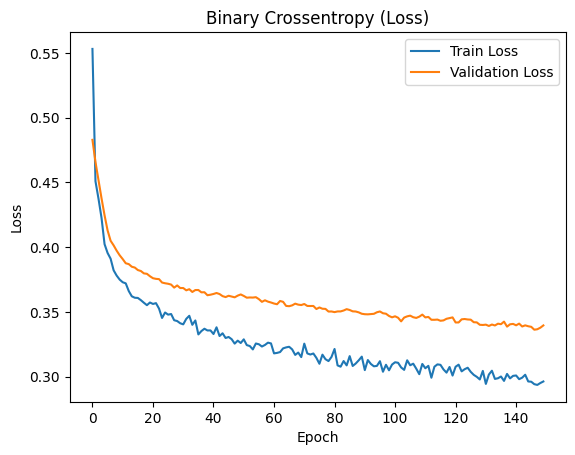

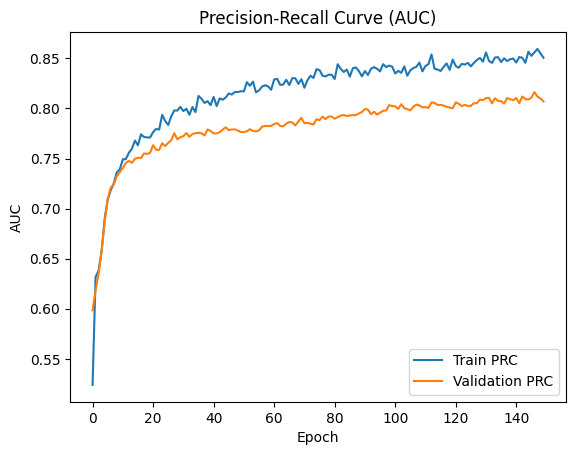

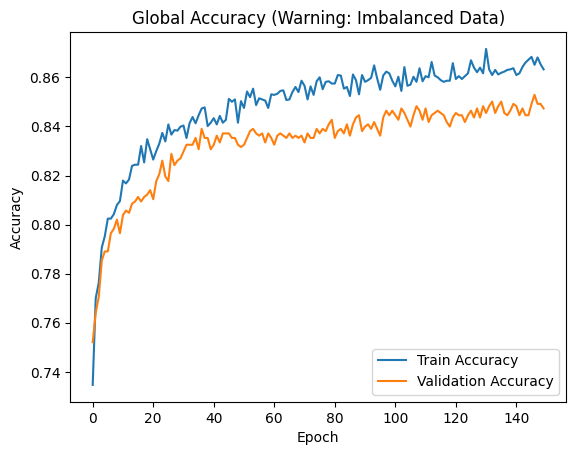

In [16]:
import matplotlib.pyplot as plt

# 1. Gráfica de la Función de Pérdida (Loss)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Binary Crossentropy (Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc="upper right")
plt.show()

# 2. Gráfica de la métrica principal para desbalanceo (PRC)
plt.plot(history.history['PRC'], label='Train PRC')
plt.plot(history.history['val_PRC'], label='Validation PRC')
plt.title('Precision-Recall Curve (AUC)')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend(loc="lower right")
plt.show()

# 3. Gráfica de Accuracy (Opcional, solo como referencia secundaria)
plt.plot(history.history['ACC'], label='Train Accuracy')
plt.plot(history.history['val_ACC'], label='Validation Accuracy')
plt.title('Global Accuracy (Warning: Imbalanced Data)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc="lower right")
plt.show()

## <font color="#CA3532">Evaluación de la red neuronal</font>


In [17]:
# Evaluation (similar to Fit in that it runs one epoch over all the data, but without changing any of the neural network's weights)
loss, accuracy, precision, recall, auc, prc = nn.evaluate(x_train, y_train)
print('Train Accuracy: %.2f' % (accuracy * 100))
print('Train Precision: %.2f' % (precision * 100))
print('Train Recall: %.2f' % (recall * 100))
print('Train AUC: %.2f' % (auc * 100))
print('Train PRC: %.2f' % (prc * 100))

print("-" * 30)

loss, accuracy, precision, recall, auc, prc = nn.evaluate(x_val, y_val)
print('Validation Accuracy: %.2f' % (accuracy * 100))
print('Validation Precision: %.2f' % (precision * 100))
print('Validation Recall: %.2f' % (recall * 100))
print('Validation AUC: %.2f' % (auc * 100))
print('Validation PRC: %.2f' % (prc * 100))

 67/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - ACC: 0.8880 - P: 0.8229 - PRC: 0.8997 - R: 0.7937 - auc: 0.9493 - loss: 0.2666

E0000 00:00:1777501276.486054  260212 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ACC: 0.8839 - P: 0.8225 - PRC: 0.8848 - R: 0.7707 - auc: 0.9471 - loss: 0.2696
Train Accuracy: 88.39
Train Precision: 82.25
Train Recall: 77.07
Train AUC: 94.71
Train PRC: 88.48
------------------------------
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - ACC: 0.8474 - P: 0.7676 - PRC: 0.8070 - R: 0.6877 - auc: 0.9118 - loss: 0.3395
Validation Accuracy: 84.74
Validation Precision: 76.76
Validation Recall: 68.77
Validation AUC: 91.18
Validation PRC: 80.70


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


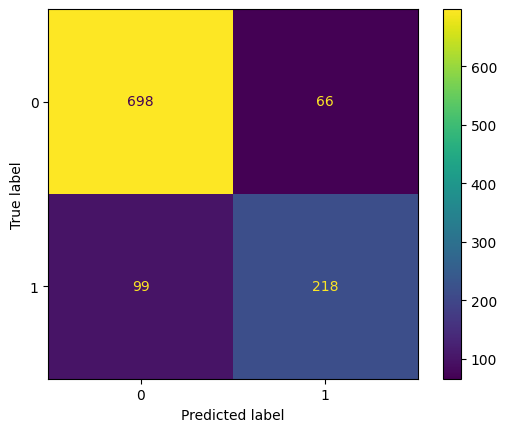

              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89       764
         1.0       0.77      0.69      0.73       317

    accuracy                           0.85      1081
   macro avg       0.82      0.80      0.81      1081
weighted avg       0.84      0.85      0.84      1081



In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# In addition to "evaluate", there is another method, "predict", which is used to label unlabeled data.
y_pred = nn.predict(x_val)
y_pred = y_pred > 0.5

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print(classification_report(y_val, y_pred))

- Modify the neural network architecture by adding more layers and neurons to achieve better results:
  - Add more layers or different types of layers.
  - Change the activation functions.
  - Change the loss function or the optimizer.

Tras comparar los nuevos resultados con el texto, el único valor que ha cambiado es el punto final de la curva Train PRC en la gráfica (que ahora llega a ~0.85 en la época 150 en lugar de ~0.88). El resto de métricas, valores de la matriz de confusión, loss, accuracy y parámetros del modelo coinciden con lo ya descrito. Aquí el texto completo con esa corrección aplicada:

***

### Question 3: Explain in detail the tests carried out and the results obtained.

**Respuesta:**

**1. Pruebas realizadas (Tests carried out):**
Dado que el concepto de "pruebas" abarca tanto las de red neuronal como las de evaluación de datos, se dividen en dos bloques:

*A) Pruebas de diseño y experimentación sobre la red neuronal:*
Partíamos de un modelo base inicial simple (una capa oculta, función `sigmoid` y 20 épocas). Para intentar mejorar su rendimiento frente a la clase minoritaria, se realizaron las siguientes pruebas de configuración:
*   **Aumento de profundidad y neuronas:** Se pasó a tener dos capas ocultas en forma piramidal (32 y 16 neuronas) para extraer características no lineales más complejas.
*   **Cambio de activación:** Las capas ocultas usaron `ReLU` en lugar de `sigmoid` para prevenir el "desvanecimiento del gradiente" y evitar estancamientos en mínimos locales.
*   **Inclusión de Regularización:** Se añadió `Dropout` (20%) tras la primera capa para apagar neuronas aleatoriamente y evitar la mera memorización de patrones (sobreajuste).
*   **Aumento de iteraciones:** Se probaron con 150 `epochs` para asegurar el aprendizaje al añadir profundidad y dar tiempo a que las curvas se estabilicen.

*B) Pruebas de evaluación del rendimiento (Métricas y Testing):*
*   **Partición de datos:** Las pruebas se realizaron aislando un 20% del dataset original como conjunto de test/validación. Se aplicó *estratificación* (`stratify`) para garantizar que la distribución desbalanceada (mayoría 0s, minoría 1s) estuviera idénticamente representada.
*   **Monitorización dinámica en tiempo de entrenamiento (graficadas por época):** Para observar el proceso de aprendizaje de la red iteración a iteración, se calcularon y graficaron continuamente para *train* y *validation*:
    *   La **Pérdida (Binary Crossentropy Loss):** Vital para ver gráficamente cómo la red reducía sus errores.
    *   El **Área bajo la Curva PR (PRC AUC):** Usada dinámicamente como la métrica macro más importante (al no usar Verdaderos Negativos) para asegurar que la red mejoraba en su tratamiento del desbalanceo paso a paso.
    *   La **Exactitud (Accuracy):** Como referencia secundaria global. Evaluar estas gráficas época a época fue la prueba para comprobar convergencia visual y detectar si emergía un indeseado sobreajuste (divergencia).
*   **Evaluación final estática (Post-entrenamiento):** Al terminar de entrenar, se congelaron los pesos y se evaluó contra el conjunto de validación completo. Como mirar la *Accuracy* pura es engañoso en estos problemas, el testing se concretó calculando la **Matriz de Confusión** e imprimiendo el **Reporte de Clasificación**, de donde sacamos resultados definitivos:
    *   **Recall (Sensibilidad):** Probó directamente la efectividad final: de todas las vocales orales (clase minoritaria), ¿cuántas capturó de verdad? (Reducción de Falsos Negativos).
    *   **Precision:** Probó la "seriedad" de la predicción final. Cuando aseguraba que era una vocal oral, ¿cuántas veces acertaba? (Reducción de Falsos Positivos).
    *   **F1-score:** La media geométrica que nos testea el rendimiento robusto final de esa clase integrando Precision y Recall.

**2. Resultados obtenidos:**
Los resultados de estas pruebas reflejan el impacto de las modificaciones tras 150 épocas de entrenamiento, evaluados tanto gráficamente como numéricamente en el conjunto de validación de 1081 muestras:

*   **Pérdida (Loss - Binary Crossentropy):** La curva `Train Loss` muestra una caída abrupta desde un pico de ~0.55 hasta ~0.40 en las primeras épocas, y a partir de ahí sigue un descenso logarítmico hasta terminar alrededor de 0.29. La `Validation Loss` también desciende rápido inicialmente (~0.48 a ~0.38) y luego baja de forma muy leve hasta estabilizarse en torno a 0.34. Ambas curvas convergen inicialmente pero forman una separación constante, señalando una evidente mejoría sin un sobreajuste severo.
*   **Curvas PRC y Resultados:** El PRC AUC en Train asciende logarítmicamente de ~0.52 hasta alcanzar ~0.85 al final, mientras que en Validation llega hasta ~0.81 tras las 150 épocas, estabilizándose de forma temprana. Muestran que el modelo logra una buena precisión y sensibilidad considerando la severa clase minoritaria.
*   **Aciertos generales (Accuracy):** Muestra una mejora logarítmica rápida al principio, alcanzando un valor aproximado de ~0.86 en entrenamiento y ~0.85 en validación. Estas métricas mantienen una brecha entre ellas consistente que se origina desde las épocas tempranas.
*   **Detección post-entrenamiento de la clase minoritaria (Clase 1 - Vocales Orales):**
    *   En las pruebas de la **matriz de confusión final**, obtuvimos 218 Verdaderos Positivos (TP) y 99 Falsos Negativos (FN), frente a los 698 Verdaderos Negativos de la clase mayoritaria y 66 Falsos Positivos. Mantiene un rendimiento respetable con la clase minoritaria.
    *   El **Recall (Sensibilidad)** en validación fue del **69%**, lo que significa que el modelo logra detectar casi el 70% de los casos de la clase minoritaria ("Vocales orales").
    *   La **Precision** post-entrenamiento se situó en un **77%** para la clase 1, indicando una proporción útil de aciertos reales cuando se emite una predicción positiva.

*Conclusión temporal:* Los tests demuestran un modelo funcional que ha ajustado bien los 737 parámetros entrenables de su combinación inicial de capas, mostrando en validación un F1-score final de **0.73** para la clase 1 (minoría) y de **0.89** para la clase 0 (mayoría) a pesar del fuerte desbalanceo original. El sobreajuste está controlado usando 150 épocas combinadas con Dropout. Aun así, sigue existiendo un sesgo obvio hacia la mayoría (89% vs 73%), y para lograr subir el recall sin destrozar la precisión se necesitarían aplicar técnicas en los apartados de optimización de RandomSearch, o técnicas explícitas de submuestreo, sobremuestreo o costes ponderados en los apartados siguientes de la práctica.

## <font color="#CA3532">Neural Network Design Optimization</font>



*Use* RandomSearch to find the hyperparameter values that improve the model’s performance. Check how it works at https://keras.io/keras_tuner/ and https://keras.io/api/keras_tuner/tuners/random/.

In [19]:
!pip install -U keras-tuner
from keras_tuner.tuners import RandomSearch

In [20]:
from keras.callbacks import EarlyStopping
from keras_tuner import Objective
from keras.layers import Input, Dense, Dropout


def build_model(hp):
    nn = Sequential()
    nn.add(Input(shape=(x_size,)))

    # Optimizamos el número de neuronas de la primera capa
    nn.add(Dense(hp.Int('units1', min_value=16,
           max_value=64, step=16), activation='relu'))

    # Optimizamos también la tasa de Dropout
    nn.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))

    # Optimizamos las neuronas de la segunda capa oculta
    nn.add(Dense(hp.Int('units2', min_value=8,
           max_value=32, step=8), activation='relu'))

    # Capa de salida para clasificación binaria
    nn.add(Dense(1, activation='sigmoid'))

    metrics = [
        keras.metrics.BinaryAccuracy(name='ACC'),
        keras.metrics.Precision(name='P'),
        keras.metrics.Recall(name='R'),
        keras.metrics.AUC(name='PRC', curve='PR'),
    ]

    # Optimizamos el learning rate del optimizador Adam
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    nn.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
               loss='binary_crossentropy',
               metrics=metrics)
    return nn


# Optimizaremos priorizando el Área bajo la Curva Precision-Recall (PRC)
# debido a que es una métrica ideal para problemas desbalanceados.
tuner = RandomSearch(
    build_model,
    objective=Objective('val_PRC', direction='max'),
    max_trials=10,
    executions_per_trial=2,
    seed=42,
    directory='busqueda_hiperparametros',
    project_name='clasificacion_vocales',
    overwrite=True
)

tuner.search_space_summary()

stop_early = EarlyStopping(
    monitor='val_PRC', patience=10, mode='max', restore_best_weights=True)

tuner.search(x_train, y_train, epochs=150, validation_data=(
    x_val, y_val), callbacks=[stop_early], verbose=0)

Search space summary
Default search space size: 4
units1 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units2 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 32, 'step': 8, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


E0000 00:00:1777501281.802152  260212 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1777501303.014175  260212 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

In [21]:
best_nn = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters()[0]

print("----- Mejores Hiperparámetros Encontrados -----")
print(f"Neuronas Capa 1: {best_hp.get('units1')}")
print(f"Tasa de Dropout: {best_hp.get('dropout')}")
print(f"Neuronas Capa 2: {best_hp.get('units2')}")
print(f"Learning Rate:   {best_hp.get('learning_rate')}")

----- Mejores Hiperparámetros Encontrados -----
Neuronas Capa 1: 64
Tasa de Dropout: 0.1
Neuronas Capa 2: 16
Learning Rate:   0.001


/home/marco/Documents/Neuro/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [22]:
tuner.results_summary()

Results summary
Results in busqueda_hiperparametros/clasificacion_vocales
Showing 10 best trials
Objective(name="val_PRC", direction="max")

Trial 09 summary
Hyperparameters:
units1: 64
dropout: 0.1
units2: 16
learning_rate: 0.001
Score: 0.8274914622306824

Trial 03 summary
Hyperparameters:
units1: 64
dropout: 0.1
units2: 32
learning_rate: 0.01
Score: 0.8255189657211304

Trial 00 summary
Hyperparameters:
units1: 48
dropout: 0.1
units2: 16
learning_rate: 0.01
Score: 0.8195399940013885

Trial 01 summary
Hyperparameters:
units1: 64
dropout: 0.2
units2: 24
learning_rate: 0.01
Score: 0.8120651841163635

Trial 05 summary
Hyperparameters:
units1: 64
dropout: 0.30000000000000004
units2: 16
learning_rate: 0.001
Score: 0.8074406683444977

Trial 04 summary
Hyperparameters:
units1: 48
dropout: 0.2
units2: 16
learning_rate: 0.001
Score: 0.8028244376182556

Trial 02 summary
Hyperparameters:
units1: 32
dropout: 0.2
units2: 32
learning_rate: 0.001
Score: 0.8008421659469604

Trial 07 summary
Hyperparam

### Question 4: Explain in detail the optimization performed and the results obtained.

**Respuesta:**

**1. Estrategia de optimización (Random Search):**
Para optimizar el modelo base definido en el apartado anterior, se ha implementado una búsqueda automatizada de hiperparámetros mediante la librería de `RandomSearch` de Keras Tuner. Se exploraron 10 combinaciones aleatorias (`max_trials=10`), ejecutando cada una 2 veces para evitar sesgos de inicialización y obtener una evaluación más robusta estadísticamente. El espacio de búsqueda definido fue:
*   **Neuronas en la 1ª capa oculta:** de 16 a 64 (en saltos de 16).
*   **Tasa de Dropout:** de 0.1 a 0.5 (del 10% al 50%).
*   **Neuronas en la 2ª capa oculta:** de 8 a 32 (en saltos de 8).
*   **Tasa de aprendizaje (Learning Rate)** del optimizador Adam: 0.01, 0.001 o 0.0001.

*Criterio de éxito y Early Stopping:* Como se justificó en las preguntas 2 y 3, no sirve evaluar el *Accuracy* o el *Loss* general dados los desbalanceos masivos. Se estableció como objetivo a maximizar el **`val_PRC` (Área bajo la Curva Precision-Recall en validación)**, priorizando así un equilibrio óptimo en la predicción de la clase minoritaria. A su vez, se añadió un *callback* de `EarlyStopping` (paciencia igual a 10 épocas) que detiene la exploración tempranamente si el `val_PRC` se estanca, devolviendo automáticamente los pesos de la mejor iteración evaluada, ahorrando tiempo de computación y mitigando el sobreajuste.

**2. Resultados obtenidos y comparativa con el modelo inicial:**
Tras evaluar el resumen de las 10 mejores iteraciones (`results_summary`), la configuración ganadora (Trial 09) resultó ser:
*   **Primera capa:** 64 neuronas.
*   **Dropout:** 0.1 (10%).
*   **Segunda capa:** 16 neuronas.
*   **Learning Rate:** 0.001.

Con esta arquitectura se alcanzó un **`val_PRC` máximo de ~0.827**, lo cual es una mejora respecto al **~0.81** obtenido con el diseño manual en la pregunta 3. De la evaluación general extraemos las siguientes conclusiones sobre la arquitectura idónea para este problema:
*   **Aumento de la capacidad de extracción (Wide First Layer):** El optimizador ha favorecido duplicar el número de neuronas iniciales (de 32 manuales a 64) en casi todas las iteraciones situadas en el "Top 5". Al haber mucho solapamiento espacial entre vocales orales y nasales, la primera capa precisa mayor dimensionalidad y receptividad para capturar fronteras complejas de entrada.
*   **Menos restricciones (Dropout más laxo):** La combinación ganadora rebajó la tasa óptima de apagado de neuronas al 10% (en lugar de 20% o tasas extremas del 40-50%). El modelo necesitaba más unidades activas encendidas para trazar detalles granulares que una penalización fuerte no le dejaba aprender.
*   **Estabilidad del Learning Rate:** El punto dulce ("sweet spot") convergente de los hiperparámetros mantuvo la tasa por defecto del Adam (0.001) o en su defecto 0.01. Los experimentos con tasas de baja alteración (0.0001 en los Trials 06 y 08) cayeron drásticamente en el "Bottom" de la tabla, con puntuaciones `val_PRC` tan empobrecidas como ~0.73, demostrando que 150 épocas no eran suficientes si el optimizador iba a dar pasos tan cortos.

En conclusión, la búsqueda hiperparamétrica determinó que el enfoque superior antes de aplicar técnicas de sobre o sub muestreo recae en una **red neuronal más ancha al inicio (64)** que reduce drásticamente las dimensiones (16) reteniendo información vital bajo un **régimen muy leve de regularización (10%)** y una convergencia normalizada (LR 0.001), aumentando así la sensibilidad a la minoría sin disparar falsas alarmas.

# <font color="#CA3532">Techniques for Unbalanced Problems</font>

We will use some techniques to prepare the data for fitting a model:

- Sampling techniques  
  - Undersampling techniques  
  - Oversampling techniques  

- Cost-sensitive learning techniques

In [23]:
!pip install -U imbalanced-learn

## <font color="#CA3532">Undersampling Technique</font>

Study how to use [RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html) from Imbalance-Learn to create a dataset (based on the original) that contains the same number of majority class examples as minority class examples. Build a model using this data and analyze the results.

**Explicación:**
Para usar `RandomUnderSampler`, instanciamos la clase definiendo la estrategia de muestreo (con `sampling_strategy='auto'`, la clase mayoritaria se reduce aleatoriamente hasta igualar el tamaño de la minoritaria). Luego, aplicamos el método `fit_resample` **exclusivamente sobre los datos de entrenamiento** (`x_train`, `y_train`). Esto es vital para no contaminar el conjunto de validación, que debe mantener la distribución original para evaluar el modelo de forma realista frente a casos futuros. Al entrenar el modelo con este nuevo conjunto balanceado, la red deja de estar sesgada hacia la clase dominante por volumen.

In [24]:
from imblearn.under_sampling import RandomUnderSampler

print("Distribución de clases original en Train:")
print(sorted(Counter(y_train).items()))

# 'auto' asegura que la clase mayoritaria se reduzca para igualar a la minoritaria
rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
# Aplicamos el muestreo SOLAMENTE en el conjunto de entrenamiento para evitar fuga de datos
x_train_us, y_train_us = rus.fit_resample(x_train, y_train)

print("Distribución de clases en Train tras aplicar Undersampling:")
print(sorted(Counter(y_train_us).items()))

Distribución de clases original en Train:
[(np.float64(0.0), 3054), (np.float64(1.0), 1269)]
Distribución de clases en Train tras aplicar Undersampling:
[(np.float64(0.0), 1269), (np.float64(1.0), 1269)]


E0000 00:00:1777502356.025890  260212 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


E0000 00:00:1777502393.673156  260212 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


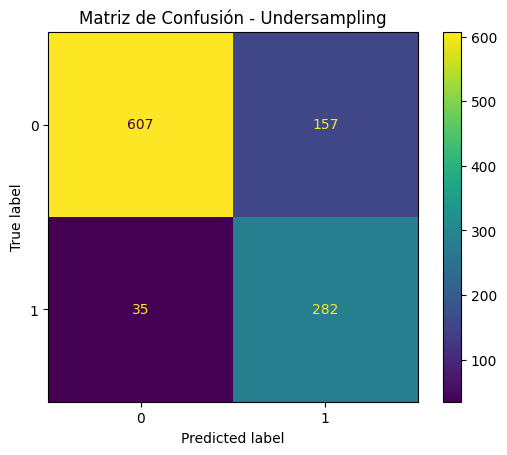

              precision    recall  f1-score   support

         0.0       0.95      0.79      0.86       764
         1.0       0.64      0.89      0.75       317

    accuracy                           0.82      1081
   macro avg       0.79      0.84      0.80      1081
weighted avg       0.86      0.82      0.83      1081



In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from keras.callbacks import EarlyStopping

# Construimos una red neuronal nueva utilizando la mejor configuración hiperparamétrica encontrada
nn_us = tuner.hypermodel.build(best_hp)

stop_early_us = EarlyStopping(
    monitor='val_PRC', patience=10, mode='max', restore_best_weights=True)

# Entrenamos con los datos balanceados (x_train_us), pero validamos con los originales (x_val)
history_us = nn_us.fit(x_train_us, y_train_us, epochs=150, verbose=0,
                       validation_data=(x_val, y_val), callbacks=[stop_early_us])

y_pred_us = nn_us.predict(x_val)
y_pred_us = y_pred_us > 0.5
cm_us = confusion_matrix(y_val, y_pred_us)
disp_us = ConfusionMatrixDisplay(confusion_matrix=cm_us)
disp_us.plot()
plt.title("Matriz de Confusión - Undersampling")
plt.show()

print(classification_report(y_val, y_pred_us))

## <font color="#CA3532">Oversampling Technique</font>

Study how to use [RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html#imblearn.over_sampling.RandomOverSampler) from Imbalance-Learn to create a dataset (based on the original) that contains the same number of minority class examples as majority class examples. Build a model using this data and analyze the results.

**Explicación:**
El uso de `RandomOverSampler` es análogo al anterior. Instanciamos la clase e indicamos `sampling_strategy='auto'` para que la técnica duplique (mediante selección aleatoria con reemplazo de las muestras originales) los ejemplos de la clase minoritaria hasta igualar en número a la clase mayoritaria. Aplicamos `fit_resample` también **solo sobre el conjunto de entrenamiento** para evitar fuga de datos (Data Leakage) hacia validación. Al entrenar con el nuevo dataset balanceado artificialmente, el modelo recibe un flujo proporcional de ambas clases y mejora en consecuencia la captura de la clase minoritaria, aunque a riesgo de presentar un mayor sobreajuste sobre estos ejemplos repetidos.

In [26]:
from imblearn.over_sampling import RandomOverSampler

print("Distribución de clases original en Train:")
print(sorted(Counter(y_train).items()))

# 'auto' asegura que la clase minoritaria iguale a la mayoritaria
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
# Aplicamos el muestreo SOLAMENTE en el conjunto de entrenamiento para evitar fuga de datos
x_train_os, y_train_os = ros.fit_resample(x_train, y_train)

print("Distribución de clases en Train tras aplicar Oversampling:")
print(sorted(Counter(y_train_os).items()))

Distribución de clases original en Train:
[(np.float64(0.0), 3054), (np.float64(1.0), 1269)]
Distribución de clases en Train tras aplicar Oversampling:
[(np.float64(0.0), 3054), (np.float64(1.0), 3054)]


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


E0000 00:00:1777502452.090712  260212 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


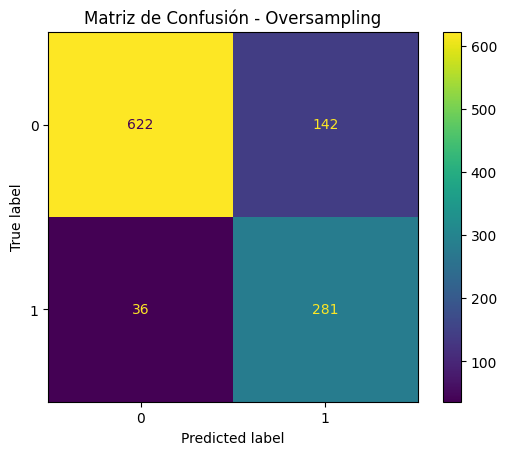

              precision    recall  f1-score   support

         0.0       0.95      0.81      0.87       764
         1.0       0.66      0.89      0.76       317

    accuracy                           0.84      1081
   macro avg       0.80      0.85      0.82      1081
weighted avg       0.86      0.84      0.84      1081



In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from keras.callbacks import EarlyStopping

# Construimos una red neuronal nueva utilizando la mejor configuración hiperparamétrica encontrada
nn_os = tuner.hypermodel.build(best_hp)

stop_early_os = EarlyStopping(
    monitor='val_PRC', patience=10, mode='max', restore_best_weights=True)

# Entrenamos con los datos sobremuestreados (x_train_os), pero validamos con los originales (x_val)
history_os = nn_os.fit(x_train_os, y_train_os, epochs=150, verbose=0,
                       validation_data=(x_val, y_val), callbacks=[stop_early_os])

y_pred_os = nn_os.predict(x_val)
y_pred_os = y_pred_os > 0.5
cm_os = confusion_matrix(y_val, y_pred_os)
disp_os = ConfusionMatrixDisplay(confusion_matrix=cm_os)
disp_os.plot()
plt.title("Matriz de Confusión - Oversampling")
plt.show()

print(classification_report(y_val, y_pred_os))

## <font color="#CA3532">Cost-Sensitive Learning Technique</font>

Study how to use the `class_weight` parameter of the [fit](https://keras.io/api/models/model_training_apis/) method in Keras to assign a different weight to each class, so that this is taken into account during training. Build a model using `class_weight` with the original data and analyze the results.

**Explicación:**
En lugar de modificar el conjunto de datos (creando copias o eliminando muestras como en el sub- y sobre-muestreo), el aprendizaje sensible al coste (Cost-Sensitive Learning) modifica cómo el algoritmo valora los aciertos o errores durante el entrenamiento. Utilizamos la función `compute_class_weight` (`class_weight='balanced'`) pasándole las etiquetas de entrenamiento originales (`y_train`) para calcular un peso inversamente proporcional a la frecuencia de cada clase. Luego, pasamos el diccionario resultante generado en formato `{clase: peso}` al parámetro `class_weight` del método `fit()`. 

De este modo, la función de pérdida (`Loss`) penaliza matemáticamente de forma más intensa a los errores cometidos en los ejemplos de la clase minoritaria (vocales orales, que tienen un peso mayor calculado que las nasales). El modelo ya no puede priorizar minimizar la pérdida a costa de acertar a ciegas en la clase dominante, al salirle mucho más "caro" fallar a la minoritaria.

Pesos calculados para cada clase (basado en Training):
{np.float64(0.0): np.float64(0.7077603143418467), np.float64(1.0): np.float64(1.7033096926713949)}
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

E0000 00:00:1777502523.423392  260212 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


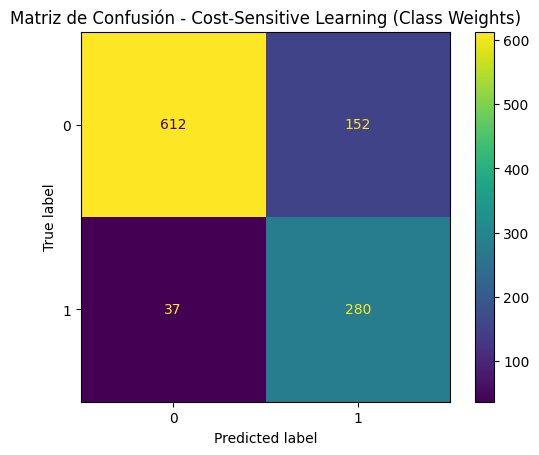

              precision    recall  f1-score   support

         0.0       0.94      0.80      0.87       764
         1.0       0.65      0.88      0.75       317

    accuracy                           0.83      1081
   macro avg       0.80      0.84      0.81      1081
weighted avg       0.86      0.83      0.83      1081



In [28]:
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import EarlyStopping

# Calculamos los pesos dinámicamente según la proporción inversa de frecuencias
# utilizando estrictamente el conjunto de entrenamiento (y_train)
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Pesos calculados para cada clase (basado en Training):")
print(class_weight_dict)

# Construimos una red neuronal nueva utilizando la mejor configuración hiperparamétrica encontrada
nn_cw = tuner.hypermodel.build(best_hp)

stop_early_cw = EarlyStopping(
    monitor='val_PRC', patience=10, mode='max', restore_best_weights=True)

# Entrenamos con los sets originales (x_train, y_train) pesados y validamos con originales
history_cw = nn_cw.fit(x_train, y_train, epochs=150, verbose=0,
                       class_weight=class_weight_dict, validation_data=(
                           x_val, y_val),
                       callbacks=[stop_early_cw])

y_pred_cw = nn_cw.predict(x_val)
y_pred_cw = y_pred_cw > 0.5
cm_cw = confusion_matrix(y_val, y_pred_cw)
disp_cw = ConfusionMatrixDisplay(confusion_matrix=cm_cw)
disp_cw.plot()
plt.title("Matriz de Confusión - Cost-Sensitive Learning (Class Weights)")
plt.show()

print(classification_report(y_val, y_pred_cw))

### Question 5: Describe the experiments carried out and the results obtained. You may combine these techniques with hyperparameter search to optimize the models.

**Respuesta:**

**1. Descripción de los experimentos realizados:**

Para abordar el severo desbalanceo de clases detectado en el conjunto de datos (donde las vocales nasales de la clase 0 superan con creces a las vocales orales de la clase 1: 3054 frente a 1269 en entrenamiento), se plantearon tres enfoques independientes. Estos experimentos partieron de la mejor estructura de red obtenida en el apartado de búsqueda de hiperparámetros (una red con una primera capa ancha de 64 neuronas, baja tasa de regularización *dropout* del 10% y una segunda capa de 16 neuronas):

*   **Undersampling (Submuestreo aleatorio):** Se igualó el número de muestras reduciendo aleatoriamente la clase mayoritaria en entrenamiento (pasando de 3054 a 1269 muestras), equiparándola a la minoritaria. Esto forzó a la red a no sesgarse por volumen, pero implicó una enorme pérdida de información útil que caracterizaba a la clase dominante.
*   **Oversampling (Sobremuestreo aleatorio):** Se equilibraron las clases mediante la duplicación con reemplazo de las muestras de la clase minoritaria en entrenamiento (subiendo de 1269 a 3054 muestras). De esta forma, se conservó toda la información de la clase original mayoritaria, aunque exponiendo al modelo a posibles sobreajustes referidos a la minoría repetida.
*   **Cost-Sensitive Learning (Pesos de clase balanceados):** A diferencia de las técnicas de muestreo, aquí no se alteró el volumen de los datos. Se calculó el peso inversamente proporcional a la frecuencia de aparición de cada clase en entrenamiento (*peso de ~0.71 para la clase 0, y ~1.70 para la clase 1*), instruyendo a la función de pérdida (*Loss*) para que penalizara los fallos sobre las vocales orales con mucho mayor impacto que los correspondientes a orales.

*Consideraciones metodológicas fundamentales:* 
*   **Inicialización sin sesgos (Uso de build):** Aunque los tres enfoques partieron de la arquitectura óptimizada encontrada por la búsqueda hiperparamétrica (`RandomSearch`), es vital destacar que **no heredaron los pesos entrenados** de dicho modelo. Para cada experimento se instanció una red neuronal nueva desde cero ejecutando explícitamente `tuner.hypermodel.build(best_hp)`. Esto garantizó que cada algoritmo partiera de un estado en blanco, permitiendo analizar el impacto real de las técnicas de balanceo sin arrastrar convergencias ni sesgos previos.
*   **Prevención de la fuga de datos (Data Leakage):** En los experimentos de *Undersampling* y *Oversampling*, la transformación de los datos se aplicó **exclusivamente sobre el conjunto de entrenamiento**. El conjunto de validación se mantuvo inalterado y con su desbalanceo original (1081 muestras). Esto es imperativo para evitar la fuga de datos (por ejemplo, que ejemplos duplicados cayeran en test) y asegurar que el rendimiento se mida frente a escenarios de la vida real donde la proporción de clases siempre será desigual.

**2. Análisis exhaustivo de los resultados (El "Trade-off" de clasificación):**

Al evaluar los tres modelos frente al conjunto de validación y compararlos con el modelo base original, observamos un cambio radical en el comportamiento de la red neuronal, caracterizado por un claro *trade-off* (compromiso) empírico entre sensibilidad y precisión:

*   **Aumento dramático de la Sensibilidad (Recall) en la clase minoritaria:** 
    El modelo inicial ignoraba una cantidad considerable de vocales orales (dejando 99 Falsos Negativos y obteniendo un *Recall* del solo **69%**). Al implementar cualquiera de las tres técnicas, la red redirigió su esfuerzo a detectar la clase 1: los Falsos Negativos cayeron abruptamente a 35 (Undersampling), 36 (Oversampling) y 37 (Cost-Sensitive). Esto supuso elevar el *Recall* en todos los casos hasta un extraordinario entorno del **~88-89%**. La red aprendió a "atrapar" casi todos los casos positivos reales.

*   **Degradación de la Precisión y aumento de Falsos Positivos:** 
    Como contrapartida aritmética inevitable al aumentar tanto la sensibilidad, la red se volvió mucho más "permisiva" o desconfiada a la hora de predecir la clase 1. Al intentar no fallar ninguna vocal oral, el modelo comenzó a clasificar erróneamente muchísimas vocales nasales (clase 0) como orales. Los Falsos Positivos pasaron de 66 en el modelo original, a dispararse a 157 (Undersampling), 142 (Oversampling) y 152 (Cost-Sensitive). Consecuentemente, la Precisión sobre las vocales orales se desplomó del **77%** original a valores en torno al **64-66%**.

*   **Comportamiento comparado de las técnicas (F1-score):**
    *   **Undersampling:** Resultó ser la técnica que generó la mayor cantidad de Falsos Positivos (157). Al haber descartado 1785 ejemplos de la clase mayoritaria durante el entrenamiento, la red topó con un déficit de información bidimensional de las vocales nasales provocando más confusiones. Su F1-score quedó en un **0.75**.
    *   **Cost-Sensitive Learning:** Ofreció un comportamiento intermedio (152 Falsos Positivos y F1-score de **0.75**). Al no requerir alterar los datos, resultó ser elegante computacionalmente, pero la penalización agresiva (~1.70 frente a ~0.71) indujo distorsiones de la frontera provocando bastantes falsas alarmas de clase 1.
    *   **Oversampling:** Mostró el **mejor equilibrio general**. Presentó el menor número de Falsos Positivos (142) de entre los tres enfoques de balanceo, alcanzando el F1-Score más alto para la clase minoritaria (**0.76**). Al conservar los 3054 casos de la clase dominante e incrementar artificialmente la presencia de la minoría, la red profunda pudo modelar una frontera de decisión más robusta.

**Conclusión:**
Los experimentos demuestran numéricamente que las técnicas de balanceo son herramientas vitales, especialmente cuando un Falso Negativo tiene un coste de ignorancia altísimo. El *Oversampling* se erige como el mejor enfoque para estos datos, elevando el F1-Score de la minoría de 0.73 a 0.76 por el mero hecho de no destruir datos originales, logrando el equilibrio menos traumático entre acertar vocales orales sin inundar el sistema con falsas clasificaciones.

<font color="#CA3532">Question 6: General Conclusions</font>

Summarize the work done in this practice and the conclusions you have drawn.

**Respuesta:**

**Reflexión Final y Conclusiones Generales**

A lo largo de esta práctica, nos hemos enfrentado a un desafío clásico y fundamental en el aprendizaje automático: la clasificación en escenarios con **conjuntos de datos severamente desbalanceados**. El caso de estudio centrado en la catalogación de fonemas (vocales nasales frente a vocales orales) ha servido como vehículo perfecto para demostrar que las metodologías operativas estándar, que a menudo priorizan ciegamente la "Exactitud" (Accuracy), son insuficientes y engañosas bajo estas condiciones.

A partir del desarrollo iterativo del modelo, se pueden extraer las siguientes **conclusiones estructurales e instrumentales**:

**1. La trampa de la Exactitud (Accuracy) y el poder de las Métricas Alternativas:**
Desde el análisis exploratorio preliminar se constató la enorme superioridad numérica de las vocales nasales (clase 0) que dominaban sobre las orales. La primera conclusión vital del trabajo fue rechazar radicalmente el Accuracy como métrica guía; un modelo ingenuo habría logrado un alto rendimiento general (superior al 70%) simplemente ignorando por completo la clase minoritaria. Se demostró la necesidad imperativa de adoptar el **Área bajo la Curva Precision-Recall (PRC AUC)**, la **Precision**, el **Recall (Sensibilidad)** y el **F1-Score**. Estas métricas expusieron la verdadera debilidad del modelo profundo inicial: su incapacidad para capturar consistentemente las vocales orales (clase 1) sin hundir la calidad de la precisión.

**2. El impacto de la Búsqueda Hiperparamétrica Automática (RandomSearch):**
Al delegar la arquitectura de las capas ocultas y las tasas de aprendizaje al optimizador Keras Tuner (maximizando estrictamente el `val_PRC`), el algoritmo nos descubrió la topología ideal frente al espacio de características tan solapado que teníamos. La red concluyó que requería **ser más ancha en su fase de recepción (64 neuronas)** para mapear la densidad multivariante, y operar con un régimen de **regularización muy suave (Dropout estricto al 10%)** para no apagar excesivamente detalles sutiles. La optimización automatizada probó ser estadísticamente superior al diseño manual guiado por intuición empírica, subiendo el valor del PRC AUC de ~0.81 hasta rozar el ~0.83 de manera estable y con "Early Stopping", antes incluso de aplicar tratamientos directos sobre el desbalanceo.

**3. Acondicionamiento de Datos y Algorítmico: El inevitable "Trade-Off":**
La fase final del estudio demostró empíricamente cómo las redes neuronales pueden ser reeducadas explícitamente para priorizar la clase minoritaria a nivel fundamental. Las tres técnicas aplicadas (Submuestreo, Sobremuestreo y Class Weights) forzaron, de forma exitosa y contundente, una **reducción drástica de Falsos Negativos**, elevando la sensibilidad en la detección de la variante minoritaria (Recall) en torno al envidiable umbral del **88-89%**. 

Sin embargo, el experimento corroboró una estricta ley del Machine Learning: el ajuste artificial de la frontera de decisión genera un **coste inevitable (Trade-off) reflejado en un aumento de Falsos Positivos**, reduciendo la Precisión general del sistema.
*   El **Undersampling**, al descartar masivamente varianza de las vocales nasales para lograr el equilibrio numérico en el entrenamiento, destruyó conocimiento útil y se coronó como el abordaje que introdujo la mayor tasa de error o confusión. 
*   El **Cost-Sensitive Learning**, aunque elegante computacionalmente y totalmente respetuoso con las proporciones originales, penalizó asimétricamente a la función de pérdida forzando a la red a desconfiar y causar una excesiva sobrepredicción preventiva de la clase menor.
*   El **Oversampling** despuntó sólidamente como la estrategia dominante para esta naturaleza de datos. Al mantener intacta la matriz geométrica del componente mayoritario y amplificar por clonado el minoritario, permitió a la red aprender los márgenes con la mayor fidelidad posible, logrando el compromiso óptimo y el **mejor F1-Score (0.76)** para las vocales orales.

**Conclusión Definitiva:**
Resolver una red neuronal compleja o un problema con fuertes desigualdades de clase no consiste únicamente en añadir neuronas, sino en **orquestar el entrenamiento bajo una teleología integral**. Esta práctica culmina demostrando que un clasificador útil nace de la fusión entre elegir una métrica de impacto adaptada a lo minoritario (val_PRC), optimizar su topología probabilísticamente, y aplicar transformaciones sobremuestreadas vigilando en todo momento que exista una partición completamente segregada de Validación, garantizando que todo el aprendizaje simulado posea sentido para el mundo real.